# Clasificación de actividades humanas mediante CNN 1D y CNN 1D + LSTM.
Este notebook realiza un pipeline completo de clasificación de actividad humana a partir de señales de acelerómetro.

El objetivo es convertir series temporales crudas en una predicción de la actividad realizada.

Para ello vamos a utilizar una CNN 1D en PyTorch para procesar las 3 señales del acelerometro (X, Y, Z).

In [1]:
import os
import numpy as np
import pandas as pd

# Visualizacion
from matplotlib import pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED = 42
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_EVAL = 128
MAX_EPOCHS_FINAL = 30

np.random.seed(SEED)
torch.manual_seed(SEED)

## Carga de datos y validación inicial

En esta sección cargamos los datos originales y fijamos una convención de nombres más clara que la de los csv originales:

- `data`: conjunto etiquetado completo.
- `predict`: conjunto sin etiquetas para inferencia final.

In [3]:
data = pd.read_csv('data/train.csv')
predict = pd.read_csv('data/test.csv')

print('Shapes:', (data.shape, predict.shape))
print('Columns in data but not in predict:', set(data.columns) - set(predict.columns))

assert set(f'{l}{i}' for i in range(1, 201) for l in 'XYZ') == set(predict.columns)

Shapes: ((9920, 602), (5120, 600))
Columns in data but not in predict: {'LABEL', 'USER_ID'}


In [4]:
feature_cols = [c for c in predict.columns if c[:1] in {'X', 'Y', 'Z'} and c[1:].isdigit()]
feature_cols = sorted(feature_cols, key=lambda c: (c[0], int(c[1:])))

def to_nested_features(df, cols):
    nested = df[cols].copy()
    nested.columns = pd.MultiIndex.from_tuples(
        [(c[0], int(c[1:])) for c in cols],
        names=['axis', 'sample']
    )

    if 'LABEL' in df.columns and 'USER_ID' in df.columns:
        nested[("META", "LABEL")] = df["LABEL"].to_numpy()
        nested[("META", "USER_ID")] = df["USER_ID"].to_numpy()

    return nested

data = to_nested_features(data, cols=feature_cols)
predict = to_nested_features(predict, cols=feature_cols)

In [5]:
data.head()

axis           X                                                        \
sample         1          2          3         4          5          6   
0       1.582196   1.237512   1.280597  2.233266   2.312256   2.460662   
1      -0.495483  20.712166  15.711853  9.564985  -1.472089  -4.320520   
2       3.822643   7.472944   7.733851  8.054599  18.924117  19.766679   
3       2.393640   2.556407   2.561195  2.565982   2.697632   2.733537   
4       0.406919   0.672613   0.447611 -0.603197  -0.426068  -0.378195   

axis                                             ...         Z            \
sample         7         8         9         10  ...       193       194   
0       2.388853  2.226085  1.737783   1.728208  ...  4.667598  4.959622   
1      -4.806429 -4.772918 -4.507224  -3.552162  ...  0.007181 -1.800017   
2       7.489700 -3.662269  4.085943  11.616335  ...  4.382755  3.477959   
3       2.628217  2.477417  2.283533   2.106403  ...  4.200838  4.155359   
4       0.495483  0.378195  0.603197   0.505058  ...  5.146326  4.904568   

axis                                                                    META  \
sample       195       196        197        198        199        200 LABEL   
0       5.371328  5.230103   5.254040   5.225316   5.122390   4.473713     4   
1       1.180065  3.614396   8.435187  18.048045  12.013679  10.943721     1   
2      -1.077138 -7.190494 -10.105947  -5.996068  -1.632463   0.239364     1   
3       4.162540  3.997379   3.975836   4.085943   4.021315   4.028496     2   
4       4.753769  4.698715   4.696322   4.686747   3.837005   3.817856     4   

axis            
sample USER_ID  
0           13  
1           22  
2            1  
3           19  
4           22  

[5 rows x 602 columns]

## Primera visualización de nuestros datos.
Vamos a hacer una breve exploración de los datos. No vamos a entrar en detalles ni calcular estadísticas, simplemente pintaremos algunas muestras. En primer lugar lo haremos con matplotlib, pero en un resultado siguiente, tendremos un gráfico interactivo con plotly que nos permitirá explorar mejor las señales.

In [6]:
labels = { 1: "Skip", 2: "Twist", 3: "Jump", 4: "Step" }

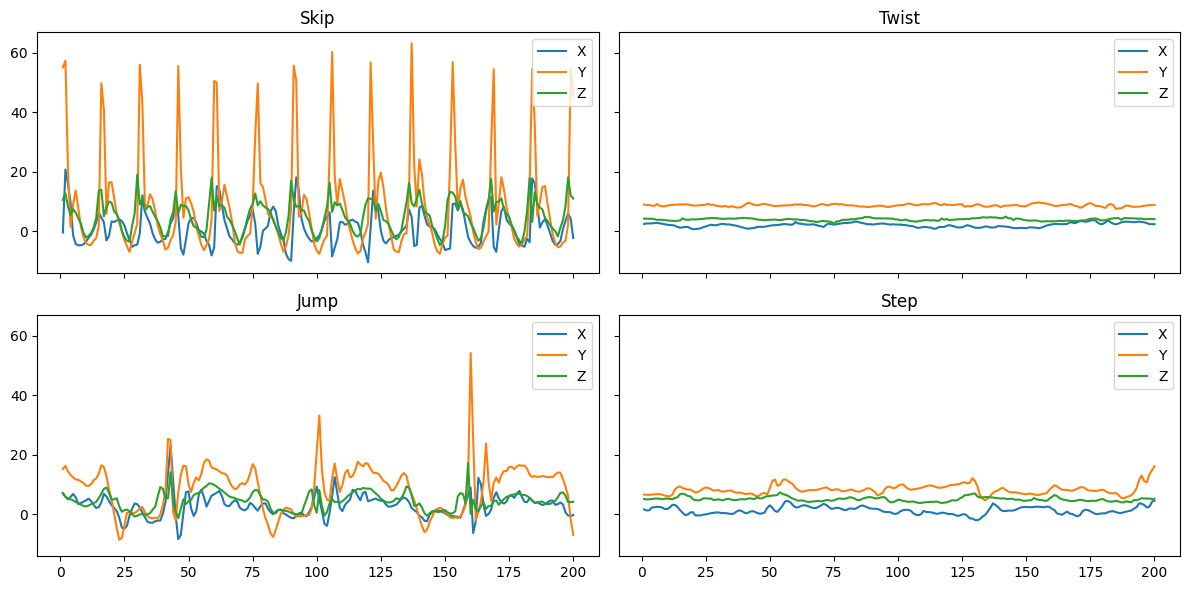

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, lbl in zip(axs.ravel(), labels.keys()):
    subset = data[data['META']['LABEL'] == lbl]
    if subset.empty:
        ax.set_title(f"{labels[lbl]} (sin muestras)")
        continue

    row = subset.iloc[0]
    ax.plot(row["X"], label="X")
    ax.plot(row["Y"], label="Y")
    ax.plot(row["Z"], label="Z")
    ax.set_title(labels[lbl])
    ax.legend()

plt.tight_layout()

Para un analisis más detallado, se ha creado este gráfico con plotly. Mediante un slider, se puede visualizar una muestra de cada clase (Skip, Twist, Jump, Step) y sus correspondientes datos de sensores. La función `make_plotly_graph` en `utils.py` se encarga de generar este gráfico interactivo (escrito en fichero aparte para mantener el notebook limpio).

In [8]:
from utils import make_plotly_graph

df_20 = data.groupby(data["META"]["LABEL"]).head(20)
make_plotly_graph(df_20, height=400, width=900)

# Prototipado Rápido (Hold-out) CNN 1D
En este notebook, se usa una partición 80/20 por grupos de sujeto para validar rápidamente que el pipeline entrena y produce métricas razonables sin esperar el coste completo de LOSO. El único notebook que en el que se ha implementado LOSO al completo es el de la CNN: `CNN.ipynb`.

## Partición del dataset por sujeto
Separamos el conjunto de entrenamiento en train/val asegurando que ningún usuario aparezca en ambos subconjuntos. Esto evita fuga de información entre particiones y hace que la evaluación sea más realista para este problema de generalización entre sujetos.

In [9]:
groups = data[("META", "USER_ID")].to_numpy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(data, groups=groups))

train_df = data.iloc[train_idx].reset_index(drop=True)
val_df = data.iloc[val_idx].reset_index(drop=True)

In [10]:
users_train = set(train_df[("META", "USER_ID")].unique())
users_val = set(val_df[("META", "USER_ID")].unique())
assert users_train.isdisjoint(users_val), "¡Error! Hay usuarios mezclados"

## Modelo en PyTorch
En esta seccion definimos una arquitectura CNN 1D para clasificacion de series temporales.

In [11]:
def pick_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

### Dataset y Funciones auxiliares

In [12]:
class ActivityDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

In [13]:
def fit_channel_scalers(X):
    scalers = []
    X_scaled = np.zeros_like(X, dtype=np.float32)
    
    for c in range(X.shape[2]):
        scaler = StandardScaler()
        X_scaled[:, :, c] = scaler.fit_transform(
            X[:, :, c].reshape(-1, 1)
        ).reshape(X.shape[0], X.shape[1])
        scalers.append(scaler)
    
    return X_scaled, scalers

def apply_channel_scalers(X, scalers):
    X_scaled = np.zeros_like(X, dtype=np.float32)
    for c in range(X.shape[2]):
        X_scaled[:, :, c] = scalers[c].transform(
            X[:, :, c].reshape(-1, 1)
        ).reshape(X.shape[0], X.shape[1])
    return X_scaled

### CNN 1D

In [14]:
class Cnn1DClassifier(nn.Module):
    def __init__(self, input_channels=3, num_classes=4, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 50, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (batch, 3, 200)
        x = self.features(x)
        return self.classifier(x)

### Funciones de entrenamiento y evaluacion

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    losses = []
    preds_all = []
    targets_all = []
    
    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)
        
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        preds = torch.argmax(logits, dim=1)
        preds_all.extend(preds.detach().cpu().numpy())
        targets_all.extend(yb.detach().cpu().numpy())
    
    acc = accuracy_score(targets_all, preds_all)
    return np.mean(losses), acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    
    losses = []
    preds_all = []
    targets_all = []
    
    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)
        
        logits = model(Xb)
        loss = criterion(logits, yb)
        
        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        
        preds_all.extend(preds.cpu().numpy())
        targets_all.extend(yb.cpu().numpy())
    
    acc = accuracy_score(targets_all, preds_all)
    cm = confusion_matrix(targets_all, preds_all)
    
    return np.mean(losses), acc, cm, np.array(preds_all), np.array(targets_all)

## Entrenamiento y evaluación

In [16]:
def df_to_seq_and_labels(df):
    X = np.stack([
        np.stack(df["X"].to_numpy()),
        np.stack(df["Y"].to_numpy()),
        np.stack(df["Z"].to_numpy()),
    ], axis=2).astype(np.float32)  # (N, 200, 3)
    y = (df[("META", "LABEL")].to_numpy().astype(np.int64) - 1)
    return X, y

X_tr, y_tr = df_to_seq_and_labels(train_df)
X_val, y_val = df_to_seq_and_labels(val_df)

X_tr_scaled, scalers = fit_channel_scalers(X_tr)
X_val_scaled = apply_channel_scalers(X_val, scalers)

# Conv1D en PyTorch usa formato (N, C, L)
X_tr_cnn = np.transpose(X_tr_scaled, (0, 2, 1)).astype(np.float32)
X_val_cnn = np.transpose(X_val_scaled, (0, 2, 1)).astype(np.float32)

device = pick_device()
patience = 8

train_ds = ActivityDataset(X_tr_cnn, y_tr)
val_ds = ActivityDataset(X_val_cnn, y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False)

model = Cnn1DClassifier(
    input_channels=3,
    num_classes=4,
    dropout=0.5,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = []
best_val_acc = -1.0
best_state = None
best_cm = None
best_preds = None
best_true = None
patience_counter = 0

for epoch in range(1, MAX_EPOCHS_FINAL + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, cm, preds, true = evaluate(model, val_loader, criterion, device)

    history.append([epoch, train_loss, train_acc, val_loss, val_acc])
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_cm = cm.copy()
        best_preds = preds.copy()
        best_true = true.copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print("\nMejor accuracy validacion rapida:", best_val_acc)

Epoch 01 | train_loss=0.5806 train_acc=0.7711 | val_loss=0.6179 val_acc=0.7781
Epoch 02 | train_loss=0.2812 train_acc=0.9176 | val_loss=0.3360 val_acc=0.8955
Epoch 03 | train_loss=0.1986 train_acc=0.9474 | val_loss=0.2648 val_acc=0.9263
Epoch 04 | train_loss=0.1722 train_acc=0.9560 | val_loss=0.3217 val_acc=0.9036
Epoch 05 | train_loss=0.1534 train_acc=0.9583 | val_loss=0.2682 val_acc=0.9174
Epoch 06 | train_loss=0.1458 train_acc=0.9607 | val_loss=0.2330 val_acc=0.9411
Epoch 07 | train_loss=0.1207 train_acc=0.9688 | val_loss=0.2485 val_acc=0.9237
Epoch 08 | train_loss=0.1179 train_acc=0.9682 | val_loss=0.2527 val_acc=0.9308
Epoch 09 | train_loss=0.1003 train_acc=0.9704 | val_loss=0.3589 val_acc=0.8746
Epoch 10 | train_loss=0.0944 train_acc=0.9728 | val_loss=0.2699 val_acc=0.9286
Epoch 11 | train_loss=0.0934 train_acc=0.9721 | val_loss=0.2524 val_acc=0.9317
Epoch 12 | train_loss=0.0865 train_acc=0.9753 | val_loss=0.4019 val_acc=0.8942
Epoch 13 | train_loss=0.0983 train_acc=0.9703 | val_

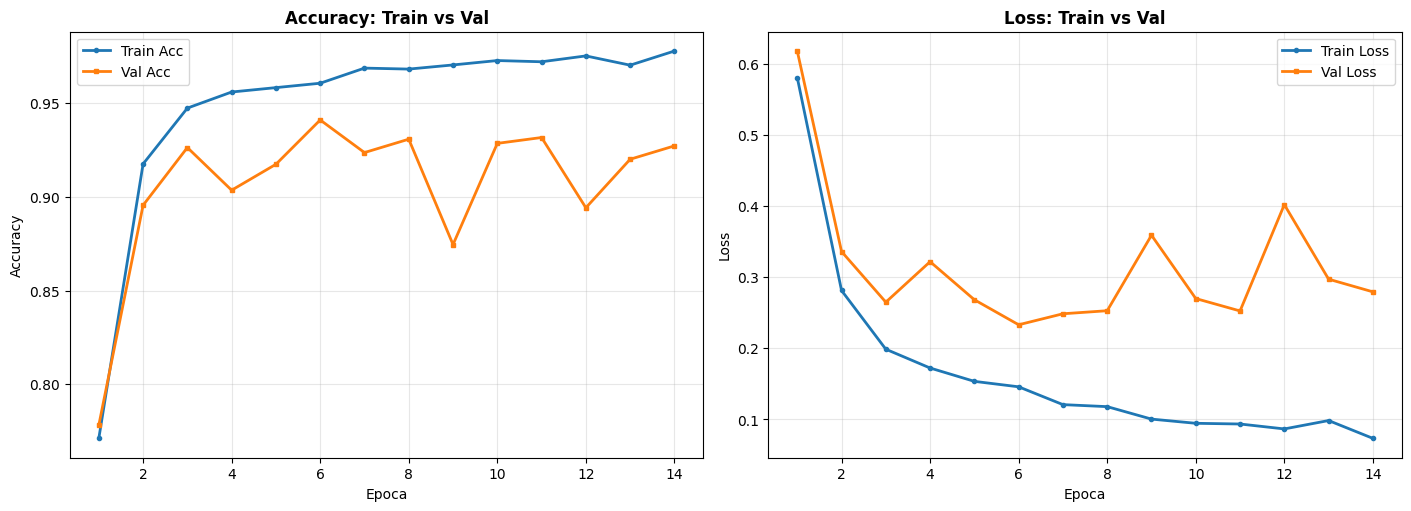

In [17]:
history = pd.DataFrame(
    history,
    columns=["epoch", "train_loss", "train_acc", "val_loss", "val_acc"]
)

fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axs[0].plot(
    history["epoch"],
    history["train_acc"],
    label="Train Acc",
    marker="o",
    markersize=3,
    linewidth=2,
    color="#1f77b4",
)
axs[0].plot(
    history["epoch"],
    history["val_acc"],
    label="Val Acc",
    marker="s",
    markersize=3,
    linewidth=2,
    color="#ff7f0e",
)
axs[0].set_title("Accuracy: Train vs Val", fontsize=12, fontweight="bold")
axs[0].set_xlabel("Epoca")
axs[0].set_ylabel("Accuracy")
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(
    history["epoch"],
    history["train_loss"],
    label="Train Loss",
    marker="o",
    markersize=3,
    linewidth=2,
    color="#1f77b4",
)
axs[1].plot(
    history["epoch"],
    history["val_loss"],
    label="Val Loss",
    marker="s",
    markersize=3,
    linewidth=2,
    color="#ff7f0e",
)
axs[1].set_title("Loss: Train vs Val", fontsize=12, fontweight="bold")
axs[1].set_xlabel("Epoca")
axs[1].set_ylabel("Loss")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.show()

## Visualización de resultados
Mediante una matriz de confusión y un resumen de las métricas obtenidas, analizamos el rendimiento del modelo sobre el conjunto de validación del hold-out.

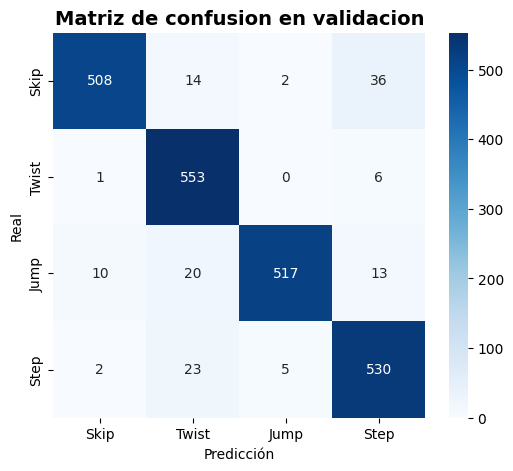

In [18]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[labels[i + 1] for i in range(4)],
    yticklabels=[labels[i + 1] for i in range(4)],
)
plt.title('Matriz de confusion en validacion', fontsize=14, fontweight='bold')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [19]:
pd.DataFrame(
    classification_report(
        best_true,
        best_preds,
        target_names=labels.values(),
        output_dict=True
    )
).T

,precision,recall,f1-score,support
Skip,0.975048,0.907143,0.939870,560.000000
Twist,0.906557,0.987500,0.945299,560.000000
Jump,0.986641,0.923214,0.953875,560.000000
Step,0.905983,0.946429,0.925764,560.000000
accuracy,0.941071,0.941071,0.941071,0.941071
macro avg,0.943557,0.941071,0.941202,2240.000000
weighted avg,0.943557,0.941071,0.941202,2240.000000


## Predicciones finales sobre `predict`
Se generan predicciones para el conjunto sin etiquetas y se exportan a un CSV nuevo con el modelo CNN 1D.

In [20]:
inference_model = model
inference_model.eval()

X_predict = np.stack([
    np.stack(predict["X"].to_numpy()),
    np.stack(predict["Y"].to_numpy()),
    np.stack(predict["Z"].to_numpy()),
], axis=2).astype(np.float32)

X_predict_scaled = apply_channel_scalers(X_predict, scalers)
X_predict_cnn = np.transpose(X_predict_scaled, (0, 2, 1)).astype(np.float32)
x_predict = torch.from_numpy(X_predict_cnn).float()
predict_loader = DataLoader(x_predict, batch_size=64, shuffle=False)

pred_labels = []
with torch.no_grad():
    for xb in predict_loader:
        logits = inference_model(xb.to(device))
        preds = torch.argmax(logits, dim=1).cpu().numpy() + 1
        pred_labels.extend(preds.tolist())

submission_df = pd.DataFrame({"y_test_pred": pred_labels})
assert len(submission_df) == len(predict), "El numero de predicciones no coincide con el test oficial"
assert submission_df["y_test_pred"].between(1, 4).all(), "Hay etiquetas fuera de [1, 4]"

submission_path = "artifacts/cnn1d_predictions.csv"
submission_df.to_csv(submission_path, index=False)

print(f"CSV generado: {submission_path}")
submission_df.head()

CSV generado: artifacts/cnn1d_predictions.csv


,y_test_pred
0,4
1,2
2,1
3,3
4,2


# Prototipado Rapido (Hold-out) CNN 1D + LSTM
En esta seccion repetimos el esquema de validacion rapida 80/20 por sujeto, pero con una arquitectura hibrida CNN 1D + LSTM en PyTorch.

## Particion del dataset por sujeto
Separamos train/val por grupos de usuario para evitar fuga de informacion entre particiones, igual que en el bloque anterior.

In [21]:
groups_lstm = data[("META", "USER_ID")].to_numpy()

gss_lstm = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_lstm, val_idx_lstm = next(gss_lstm.split(data, groups=groups_lstm))

train_df_lstm = data.iloc[train_idx_lstm].reset_index(drop=True)
val_df_lstm = data.iloc[val_idx_lstm].reset_index(drop=True)

In [22]:
users_train_lstm = set(train_df_lstm[("META", "USER_ID")].unique())
users_val_lstm = set(val_df_lstm[("META", "USER_ID")].unique())
assert users_train_lstm.isdisjoint(users_val_lstm), "Error: hay usuarios mezclados"

## Modelo en PyTorch
Definimos una arquitectura hibrida CNN 1D + LSTM para capturar patrones locales y dinamica temporal de mas largo alcance.

### Dataset y Funciones auxiliares

In [23]:
# Reutilizamos las utilidades definidas en el bloque anterior:
# - pick_device
# - ActivityDataset
# - fit_channel_scalers
# - apply_channel_scalers

### CNN 1D + LSTM

In [24]:
class Cnn1dLstmClassifier(nn.Module):
    def __init__(self, input_channels=3, lstm_hidden=64, lstm_layers=1, dropout=0.5, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.0 if lstm_layers == 1 else dropout,
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden, num_classes)

    def forward(self, x):
        # x: (batch, 3, 200)
        x = self.features(x)            # (batch, 128, 50)
        x = x.transpose(1, 2)           # (batch, 50, 128)
        x, _ = self.lstm(x)             # (batch, 50, lstm_hidden)
        x = x[:, -1, :]                 # ultimo paso temporal
        x = self.dropout(x)
        return self.classifier(x)

### Funciones de entrenamiento y evaluacion

In [25]:
def train_one_epoch_lstm(model, loader, optimizer, criterion, device):
    model.train()

    losses = []
    preds_all = []
    targets_all = []

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        preds_all.extend(preds.detach().cpu().numpy())
        targets_all.extend(yb.detach().cpu().numpy())

    acc = accuracy_score(targets_all, preds_all)
    return np.mean(losses), acc

@torch.no_grad()
def evaluate_lstm(model, loader, criterion, device):
    model.eval()

    losses = []
    preds_all = []
    targets_all = []

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        logits = model(Xb)
        loss = criterion(logits, yb)

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)

        preds_all.extend(preds.cpu().numpy())
        targets_all.extend(yb.cpu().numpy())

    acc = accuracy_score(targets_all, preds_all)
    cm = confusion_matrix(targets_all, preds_all)

    return np.mean(losses), acc, cm, np.array(preds_all), np.array(targets_all)

## Entrenamiento y evaluacion

In [26]:
def df_to_seq_and_labels_lstm(df):
    X = np.stack([
        np.stack(df["X"].to_numpy()),
        np.stack(df["Y"].to_numpy()),
        np.stack(df["Z"].to_numpy()),
    ], axis=2).astype(np.float32)
    y = (df[("META", "LABEL")].to_numpy().astype(np.int64) - 1)
    return X, y

X_tr_lstm, y_tr_lstm = df_to_seq_and_labels_lstm(train_df_lstm)
X_val_lstm, y_val_lstm = df_to_seq_and_labels_lstm(val_df_lstm)

X_tr_lstm_scaled, scalers_lstm = fit_channel_scalers(X_tr_lstm)
X_val_lstm_scaled = apply_channel_scalers(X_val_lstm, scalers_lstm)

X_tr_lstm_cnn = np.transpose(X_tr_lstm_scaled, (0, 2, 1)).astype(np.float32)
X_val_lstm_cnn = np.transpose(X_val_lstm_scaled, (0, 2, 1)).astype(np.float32)

device_lstm = pick_device()
patience_lstm = 8

train_ds_lstm = ActivityDataset(X_tr_lstm_cnn, y_tr_lstm)
val_ds_lstm = ActivityDataset(X_val_lstm_cnn, y_val_lstm)

train_loader_lstm = DataLoader(train_ds_lstm, batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader_lstm = DataLoader(val_ds_lstm, batch_size=BATCH_SIZE_EVAL, shuffle=False)

model_lstm = Cnn1dLstmClassifier(
    input_channels=3,
    lstm_hidden=64,
    lstm_layers=1,
    dropout=0.5,
    num_classes=4,
).to(device_lstm)

criterion_lstm = nn.CrossEntropyLoss()
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-4)

history_lstm = []
best_val_acc_lstm = -1.0
best_state_lstm = None
best_cm_lstm = None
best_preds_lstm = None
best_true_lstm = None
patience_counter_lstm = 0

for epoch in range(1, MAX_EPOCHS_FINAL + 1):
    train_loss_lstm, train_acc_lstm = train_one_epoch_lstm(
        model_lstm, train_loader_lstm, optimizer_lstm, criterion_lstm, device_lstm
    )
    val_loss_lstm, val_acc_lstm, cm_lstm, preds_lstm, true_lstm = evaluate_lstm(
        model_lstm, val_loader_lstm, criterion_lstm, device_lstm
    )

    history_lstm.append([epoch, train_loss_lstm, train_acc_lstm, val_loss_lstm, val_acc_lstm])
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss_lstm:.4f} train_acc={train_acc_lstm:.4f} | "
        f"val_loss={val_loss_lstm:.4f} val_acc={val_acc_lstm:.4f}"
    )

    if val_acc_lstm > best_val_acc_lstm:
        best_val_acc_lstm = val_acc_lstm
        best_state_lstm = {k: v.detach().cpu().clone() for k, v in model_lstm.state_dict().items()}
        best_cm_lstm = cm_lstm.copy()
        best_preds_lstm = preds_lstm.copy()
        best_true_lstm = true_lstm.copy()
        patience_counter_lstm = 0
    else:
        patience_counter_lstm += 1

    if patience_counter_lstm >= patience_lstm:
        print("Early stopping")
        break

if best_state_lstm is not None:
    model_lstm.load_state_dict(best_state_lstm)

print("\nMejor accuracy validacion rapida (CNN 1D + LSTM):", best_val_acc_lstm)

Epoch 01 | train_loss=0.7697 train_acc=0.7134 | val_loss=0.5816 val_acc=0.7924
Epoch 02 | train_loss=0.3832 train_acc=0.8775 | val_loss=0.3594 val_acc=0.8871
Epoch 03 | train_loss=0.2760 train_acc=0.9163 | val_loss=0.3962 val_acc=0.8754
Epoch 04 | train_loss=0.2341 train_acc=0.9307 | val_loss=0.3483 val_acc=0.8973
Epoch 05 | train_loss=0.2214 train_acc=0.9332 | val_loss=0.3237 val_acc=0.9161
Epoch 06 | train_loss=0.1986 train_acc=0.9440 | val_loss=0.3771 val_acc=0.9004
Epoch 07 | train_loss=0.1878 train_acc=0.9503 | val_loss=0.2959 val_acc=0.9196
Epoch 08 | train_loss=0.1732 train_acc=0.9556 | val_loss=1.2929 val_acc=0.7170
Epoch 09 | train_loss=0.2163 train_acc=0.9404 | val_loss=0.3520 val_acc=0.9013
Epoch 10 | train_loss=0.1723 train_acc=0.9543 | val_loss=0.2736 val_acc=0.9246
Epoch 11 | train_loss=0.1508 train_acc=0.9622 | val_loss=0.3238 val_acc=0.8996
Epoch 12 | train_loss=0.1484 train_acc=0.9621 | val_loss=0.2611 val_acc=0.9308
Epoch 13 | train_loss=0.1332 train_acc=0.9669 | val_

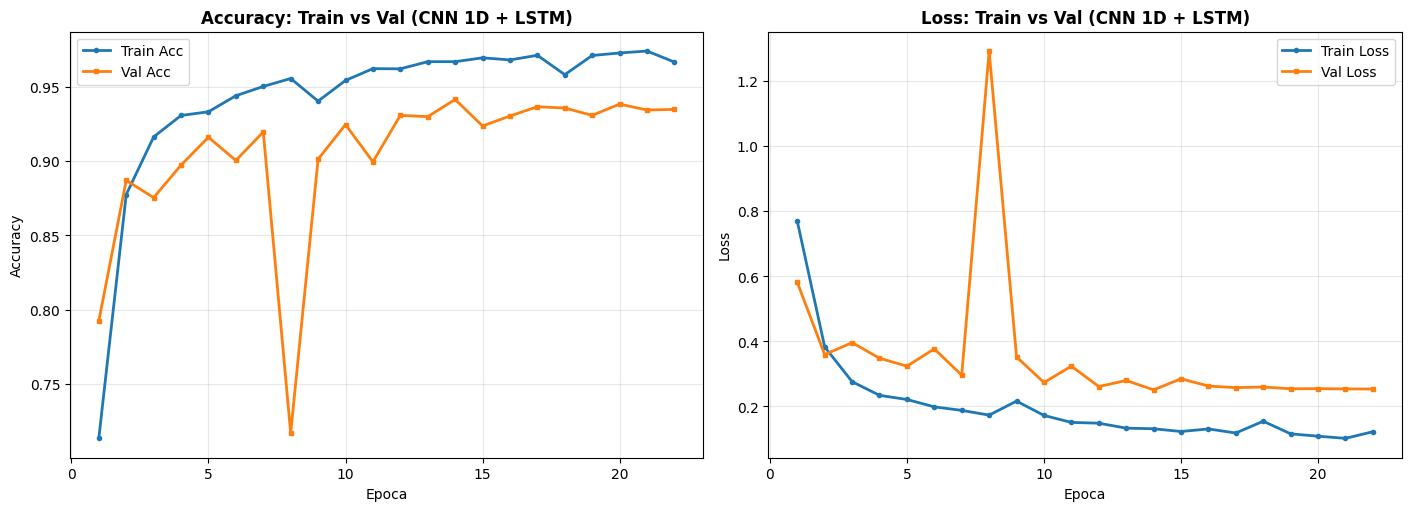

In [27]:
history_lstm = pd.DataFrame(
    history_lstm,
    columns=["epoch", "train_loss", "train_acc", "val_loss", "val_acc"]
)

fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axs[0].plot(history_lstm["epoch"], history_lstm["train_acc"], label="Train Acc", marker="o", markersize=3, linewidth=2, color="#1f77b4")
axs[0].plot(history_lstm["epoch"], history_lstm["val_acc"], label="Val Acc", marker="s", markersize=3, linewidth=2, color="#ff7f0e")
axs[0].set_title("Accuracy: Train vs Val (CNN 1D + LSTM)", fontsize=12, fontweight="bold")
axs[0].set_xlabel("Epoca")
axs[0].set_ylabel("Accuracy")
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(history_lstm["epoch"], history_lstm["train_loss"], label="Train Loss", marker="o", markersize=3, linewidth=2, color="#1f77b4")
axs[1].plot(history_lstm["epoch"], history_lstm["val_loss"], label="Val Loss", marker="s", markersize=3, linewidth=2, color="#ff7f0e")
axs[1].set_title("Loss: Train vs Val (CNN 1D + LSTM)", fontsize=12, fontweight="bold")
axs[1].set_xlabel("Epoca")
axs[1].set_ylabel("Loss")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.show()

## Visualizacion de resultados
Analizamos el rendimiento del modelo CNN 1D + LSTM sobre el conjunto de validacion del hold-out.

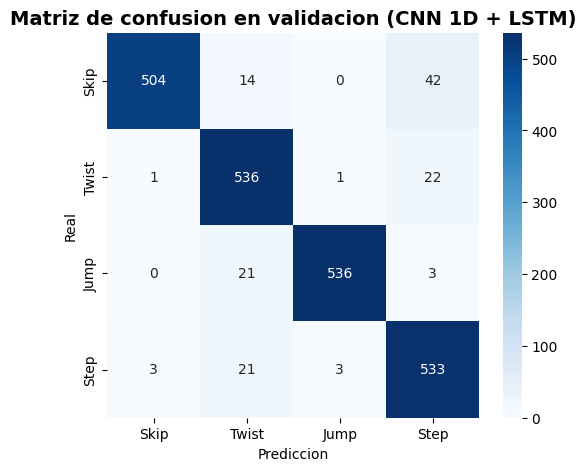

In [28]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    best_cm_lstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[labels[i + 1] for i in range(4)],
    yticklabels=[labels[i + 1] for i in range(4)],
)
plt.title('Matriz de confusion en validacion (CNN 1D + LSTM)', fontsize=14, fontweight='bold')
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.show()

In [29]:
pd.DataFrame(
    classification_report(
        best_true_lstm,
        best_preds_lstm,
        target_names=labels.values(),
        output_dict=True
    )
).T

,precision,recall,f1-score,support
Skip,0.992126,0.900000,0.943820,560.000000
Twist,0.905405,0.957143,0.930556,560.000000
Jump,0.992593,0.957143,0.974545,560.000000
Step,0.888333,0.951786,0.918966,560.000000
accuracy,0.941518,0.941518,0.941518,0.941518
macro avg,0.944614,0.941518,0.941972,2240.000000
weighted avg,0.944614,0.941518,0.941972,2240.000000


## Predicciones finales sobre `predict`
Se generan predicciones para el conjunto sin etiquetas y se exportan a un CSV nuevo con el modelo CNN 1D + LSTM.

In [30]:
inference_model_lstm = model_lstm
inference_model_lstm.eval()

X_predict_lstm = np.stack([
    np.stack(predict["X"].to_numpy()),
    np.stack(predict["Y"].to_numpy()),
    np.stack(predict["Z"].to_numpy()),
], axis=2).astype(np.float32)

X_predict_lstm_scaled = apply_channel_scalers(X_predict_lstm, scalers_lstm)
X_predict_lstm_cnn = np.transpose(X_predict_lstm_scaled, (0, 2, 1)).astype(np.float32)
x_predict_lstm = torch.from_numpy(X_predict_lstm_cnn).float()
predict_loader_lstm = DataLoader(x_predict_lstm, batch_size=64, shuffle=False)

pred_labels_lstm = []
with torch.no_grad():
    for xb in predict_loader_lstm:
        logits = inference_model_lstm(xb.to(device_lstm))
        preds = torch.argmax(logits, dim=1).cpu().numpy() + 1
        pred_labels_lstm.extend(preds.tolist())

submission_lstm_df = pd.DataFrame({"y_test_pred": pred_labels_lstm})
assert len(submission_lstm_df) == len(predict), "El numero de predicciones no coincide con el test oficial"
assert submission_lstm_df["y_test_pred"].between(1, 4).all(), "Hay etiquetas fuera de [1, 4]"

submission_lstm_path = "artifacts/cnn1d_lstm_predictions.csv"
submission_lstm_df.to_csv(submission_lstm_path, index=False)

print(f"CSV generado: {submission_lstm_path}")
submission_lstm_df.head()

CSV generado: artifacts/cnn1d_lstm_predictions.csv


,y_test_pred
0,3
1,2
2,1
3,3
4,2
